# Predicting war events

## I. Importing essential libraries

In [338]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
from tqdm import tqdm
import pymorphy3

from collections import Counter
from calendar import monthcalendar, SUNDAY

import os
from pathlib import Path
import json

## II. Importing datasets

In [339]:
df_weather = pd.read_csv("../data/all_weather_by_hour_2023-2025_v1.csv")

In [340]:
df_war_events_raw = pd.read_csv("../data/alarms-240222-010325.csv", sep=";")
df_regions = pd.read_csv("../data/regions.csv")

In [341]:
json_path_isw = Path("../data/isw_reports_v2.json")

with open(json_path_isw, "r", encoding="utf-8") as f:
    data = json.load(f)

df_isw_raw = pd.DataFrame(data)

print(type(df_isw_raw))

<class 'pandas.DataFrame'>


In [342]:
json_path_tg = Path("../data/telegram_data.json")

with open(json_path_tg, "r", encoding="utf-8") as f:
    data = json.load(f)

df_tg_raw = pd.DataFrame(data)

print(type(df_tg_raw))

<class 'pandas.DataFrame'>


## III. EDA

### Weather

In [343]:
pd.set_option("display.max_columns", None)
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [344]:
df_weather.tail()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
608299,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,19:00:00,1740848400,-1.3,-3.5,73.09,-5.5,0.0,0.0,0.0,2.0,NaN,11.5,5.8,174.9,1030.0,NaN,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608300,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,20:00:00,1740852000,-1.8,-1.8,81.17,-4.6,0.0,0.0,0.0,2.0,NaN,13.0,0.0,170.5,1029.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999
608301,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,21:00:00,1740855600,-1.0,-3.5,68.31,-6.1,0.0,0.0,0.0,2.0,NaN,11.9,6.8,168.7,1029.0,NaN,99.6,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608302,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,22:00:00,1740859200,-1.7,-4.5,71.36,-6.2,0.0,0.0,0.0,2.0,NaN,12.6,7.2,173.4,1029.0,NaN,98.2,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608303,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,23:00:00,1740862800,-2.1,-2.1,84.88,-4.3,0.0,0.0,0.0,2.0,NaN,13.0,0.0,182.0,1028.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999


In [345]:
rows, columns = df_weather.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 608304, columns: 65


In [346]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  str    
 3   city_address          608304 non-null  str    
 4   city_timezone         608304 non-null  str    
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  str    
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  day_humidit

In [347]:
df_weather.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex
count,608304.000000,608304.000000,608304.0,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,552952.000000,607752.000000,607752.000000,607752.000000,6.083040e+05,6.083040e+05,608304.000000,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608202.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.00000,331846.000000,608304.000000,603968.000000,521042.000000,603968.000000
mean,49.143238,30.142514,2.0,1.693217e+09,15.203232,6.253993,10.721077,14.287248,4.267318,9.254504,5.285646,72.891185,2.095628,53.533924,6.553061,0.121132,0.598356,34.879037,18.545700,191.158465,1016.920939,64.812537,14.917199,141.953237,12.242466,4.806077,1.693240e+09,1.693284e+09,0.489195,1.693258e+09,10.719390,9.252908,72.891267,5.283823,0.087357,6.552809,0.005045,0.598141,23.769943,11.399938,189.830264,1016.91840,17.010448,64.811065,142.722294,0.595017,1.413903
std,1.337209,4.303973,0.0,2.748558e+07,10.592473,8.162055,9.207622,11.577354,9.929590,10.713666,7.473743,14.564090,10.685616,49.874998,12.103297,0.662849,1.998581,11.736481,6.887631,106.201073,8.446172,28.824705,7.753173,96.845076,8.371915,2.653499,2.748640e+07,2.748407e+07,0.289963,2.748559e+07,9.787529,11.293806,19.456422,7.652857,2.141735,24.745557,0.048299,2.615546,11.492758,6.517607,106.383976,8.68127,9.656796,37.318628,220.920973,0.828064,2.226545
min,46.472500,22.285100,2.0,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,-27.100000,-20.700000,23.300000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000,2.500000,0.000000,981.600000,0.000000,0.000000,0.000000,0.000000,0.000000,1.645676e+09,1.645715e+09,0.000000,1.645654e+09,-50.300000,-50.300000,8.460000,-25.900000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,973.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.292400,25.935500,2.0,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,-0.100000,-0.300000,62.400000,0.000000,0.000000,0.000000,0.000000,0.000000,26.600000,14.000000,98.200000,1011.500000,43.900000,9.900000,51.200000,4.400000,2.000000,1.669441e+09,1.669472e+09,0.250000,1.669456e+09,2.400000,-0.300000,59.310000,-0.400000,0.000000,0.000000,0.000000,0.000000,14.800000,7.200000,98.000000,1011.20000,10.000000,30.000000,0.000000,0.000000,0.000000
50%,49.416800,30.737100,2.0,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,9.900000,5.300000,74.200000,0.100000,100.000000,4.170000,0.000000,0.000000,33.800000,18.000000,195.600000,1016.500000,70.700000,12.500000,129.400000,11.200000,5.000000,1.693277e+09,1.693326e+09,0.500000,1.693258e+09,10.200000,10.200000,77.430000,5.300000,0.000000,0.000000,0.000000,0.000000,22.300000,10.800000,191.900000,1016.60000,15.800000,80.000000,5.600000,0.100000,0.000000
75%,50.253600,34.551700,2.0,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,18.800000,11.500000,84.800000,1.092000,100.000000,8.330000,0.000000,0.000000,41.400000,22.000000,287.000000,1022.000000,90.600000,20.000000,226.800000,19.600000,7.000000,1.717035e+09,1.717092e+09,0.750000,1.717060e+09,18.400000,18.400000,89.050000,11.500000,0.000000,0.

In [348]:
df_weather.isna().sum()

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            4336
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64

In [349]:
categorical_cols = ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description',
                    'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source',
                    'hour_source', 'day_stations', 'hour_stations']
numeric_cols = ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax',
                'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew',
                'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob',
                'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed',
                'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure',
                'day_cloudcover', 'hour_cloudcover','day_visibility', 'hour_visibility', 'day_solarradiation',
                'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy','hour_uvindex',
                'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']
time_cols = ['day_datetime', 'day_datetimeEpoch', 'hour_datetime', 'hour_datetimeEpoch',
             'day_sunrise', 'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch']

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)
print("\nTime columns:", time_cols)

Categorical columns: ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description', 'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source', 'hour_source', 'day_stations', 'hour_stations']

Numeric columns: ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax', 'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew', 'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob', 'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure', 'day_cloudcover', 'hour_cloudcover', 'day_visibility', 'hour_visibility', 'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy', 'hour_uvindex', 'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']



In [350]:
df_weather['city_address'].value_counts()

city_address
Lutsk,Ukraine              26448
Kropyvnytskyi,Ukraine      26448
Dnipro,Ukraine             26448
Kyiv,Ukraine               26448
Kherson,Ukraine            26448
Chernivtsi,Ukraine         26448
Chernihiv,Ukraine          26448
Odesa,Ukraine              26448
Mykolaiv,Ukraine           26448
Kharkiv,Ukraine            26448
Khmelnytskyi,Ukraine       26448
Donetsk,Ukraine            26448
Uzhgorod,Ukraine           26448
Zaporozhye,Ukraine         26448
Rivne,Ukraine              26448
Zhytomyr,Ukraine           26448
Ternopil,Ukraine           26448
Poltava,Ukraine            26448
Lviv,Ukraine               26448
Ivano-Frankivsk,Ukraine    26448
Cherkasy,Ukraine           26448
Sumy,Ukraine               26448
Vinnytsia,Ukraine          26448
Name: count, dtype: int64

In [351]:
df_weather['city_timezone'].value_counts()

city_timezone
Europe/Kiev          555408
Europe/Uzhgorod       26448
Europe/Zaporozhye     26448
Name: count, dtype: int64

In [352]:
df_weather['city_resolvedAddress'].value_counts()

city_resolvedAddress
Луцьк, Луцький район, Україна           26448
Кропивницький, Україна                  26448
Дніпро, Україна                         26448
Київ, Україна                           26448
Херсон, Україна                         26448
Чернівці, Україна                       26448
Чернігів, Україна                       26448
Одеса, Україна                          26448
Миколаїв, Україна                       26448
Харків, Україна                         26448
Хмельницька область, Україна            26448
Донецьк, Україна                        26448
Ужгород, Ужгородський район, Україна    26448
Запоріжжя, Україна                      26448
Рівне, Україна                          26448
Житомир, Україна                        26448
Тернопіль, Україна                      26448
Полтава, Україна                        26448
Львів, Україна                          26448
Івано-Франківськ, Україна               26448
Черкаси, Україна                        26448
Суми, Україна

In [353]:
df_weather['hour_stations'].value_counts()

hour_stations
remote                                                  403732
UUOB                                                     20591
33902099999                                              12452
15023099999;15007099999;LRSV;15000099999                 12418
33837099999                                               7528
                                                         ...  
11968099999;11993099999;LZKZ                                 1
11968099999;LZKZ                                             1
11993099999;11978099999;11927199999;LZKZ                     1
11933099999;11978099999;11927199999;33631099999;LZKZ         1
11968099999;11933099999;33631099999                          1
Name: count, Length: 154, dtype: int64

In [354]:
df_weather.duplicated().sum()

np.int64(0)

In [355]:
df_weather['day_datetime'].head()

0    2022-02-24
1    2022-02-24
2    2022-02-24
3    2022-02-24
4    2022-02-24
Name: day_datetime, dtype: str

Cheking for anomaly temperature:

In [356]:
df_weather[(df_weather["day_tempmax"] > 45) | (df_weather["day_tempmin"] < -35)]

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
106367,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,00:00:00,1656795600,18.4,18.4,58.04,10.0,0.0,0.0,0.0,0.0,NaN,7.9,4.3,356.3,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106368,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,01:00:00,1656799200,17.6,17.6,62.68,10.4,0.0,0.0,0.0,0.0,NaN,7.6,4.3,332.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106369,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,02:00:00,1656802800,16.9,16.9,68.64,11.1,0.0,0.0,0.0,0.0,NaN,6.8,4.3,327.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106370,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,03:00:00,1656806400,19.4,19.4,92.19,18.1,0.0,0.0,0.0,0.0,NaN,7.2,4.3,290.0,1020.0,2.0,40.0,0.0,NaN,0.0,Partially cloudy,partly-cloudy-night,obs,34601099999
106371,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,04:00:00,1656810000,15.8,15.8,78.66,12.1,0.0,0.0,0.0,0.0,NaN,7.2,4.3,334.2,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106372,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,05:00:00,1656813600,15.5,15.5,79.66,12.0,0.0,0.0,0.0,0.0,NaN,7.2,4.3,334.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-day,obs,remote
106373,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,1

In [357]:
df_weather.loc[
    df_weather["day_tempmin"] > df_weather["day_tempmax"],
    ["day_datetime", "day_tempmin", "day_tempmax"]
]

,day_datetime,day_tempmin,day_tempmax


In [358]:
df_weather.loc[
    (df_weather["day_temp"] < df_weather["day_tempmin"]) |
    (df_weather["day_temp"] > df_weather["day_tempmax"]),
    ["day_datetime", "day_temp", "day_tempmin", "day_tempmax"]
]

,day_datetime,day_temp,day_tempmin,day_tempmax


#### Preprocessing

In [359]:
df_weather["city_address"] = df_weather["city_address"].str.replace(",Ukraine", "")

In [360]:
df_weather["city_address"].unique()

<StringArray>
[          'Lutsk',   'Kropyvnytskyi',          'Dnipro',            'Kyiv',
         'Kherson',      'Chernivtsi',       'Chernihiv',           'Odesa',
        'Mykolaiv',         'Kharkiv',    'Khmelnytskyi',         'Donetsk',
        'Uzhgorod',      'Zaporozhye',           'Rivne',        'Zhytomyr',
        'Ternopil',         'Poltava',            'Lviv', 'Ivano-Frankivsk',
        'Cherkasy',            'Sumy',       'Vinnytsia']
Length: 23, dtype: str

The dataset does not contain data for the following cities: Luhansk, Simferopol

In [361]:
df_weather['day_datetime'] = pd.to_datetime(df_weather['day_datetime'], errors="coerce")

In [362]:
df_weather["datetime_hour"] = (
    df_weather["day_datetime"] +
    pd.to_timedelta(df_weather["hour_datetime"].astype(str))
)

df_weather["year"] = df_weather["day_datetime"].dt.year
df_weather["month"] = df_weather["day_datetime"].dt.month
df_weather["day_of_week"] = df_weather["day_datetime"].dt.dayofweek

df_weather["hour"] = df_weather["hour_datetime"].str.split(":").str[0].astype(int)

In [363]:
df_weather.groupby("month")["day_temp"].mean()

month
1      0.373446
2      0.145556
3      3.999423
4     10.330145
5     15.123843
6     20.514348
7     22.362786
8     22.743385
9     17.087005
10    11.077002
11     4.001932
12     0.907574
Name: day_temp, dtype: float64

In [364]:
df_weather["hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [365]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
0,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote,2022-02-24 00:00:00,2022,2,3,0
1,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote,2022-02-24 01:00:00,2022,2,3,1
2,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999,2022-02-24 02:00:00,2022,2,3,2
3,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote,2022-02-24 03:00:00,2022,2,3,3
4,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote,2022-02-24 04:00:00,2022,2,3,4


In [366]:
df_weather['day_solarradiation'] = df_weather['day_solarradiation'].fillna(df_weather['day_solarradiation'].median())
df_weather['day_solarenergy'] = df_weather['day_solarenergy'].fillna(df_weather['day_solarenergy'].median())
df_weather['day_uvindex'] = df_weather['day_uvindex'].fillna(df_weather['day_uvindex'].median())

df_weather['hour_solarradiation'] = df_weather['hour_solarradiation'].fillna(df_weather['hour_solarradiation'].median())
df_weather['hour_solarenergy'] = df_weather['hour_solarenergy'].fillna(df_weather['hour_solarenergy'].median())
df_weather['hour_uvindex'] = df_weather['hour_uvindex'].fillna(df_weather['hour_uvindex'].median())

df_weather['hour_precip'] = df_weather['hour_precip'].fillna(0)

In [367]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
0,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,0.1,0.0,Overcast,snow,obs,remote,2022-02-24 00:00:00,2022,2,3,0
1,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,0.1,0.0,Partially cloudy,fog,obs,remote,2022-02-24 01:00:00,2022,2,3,1
2,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,5.6,0.1,0.0,Overcast,cloudy,obs,33177099999,2022-02-24 02:00:00,2022,2,3,2
3,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,0.1,0.0,Overcast,fog,obs,remote,2022-02-24 03:00:00,2022,2,3,3
4,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,0.1,0.0,Overcast,cloudy,obs,remote,2022-02-24 04:00:00,2022,2,3,4


In [368]:
df_weather.tail()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
608299,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,19:00:00,1740848400,-1.3,-3.5,73.09,-5.5,0.0,0.0,0.0,2.0,NaN,11.5,5.8,174.9,1030.0,NaN,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 19:00:00,2025,3,5,19
608300,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,20:00:00,1740852000,-1.8,-1.8,81.17,-4.6,0.0,0.0,0.0,2.0,NaN,13.0,0.0,170.5,1029.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999,2025-03-01 20:00:00,2025,3,5,20
608301,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,21:00:00,1740855600,-1.0,-3.5,68.31,-6.1,0.0,0.0,0.0,2.0,NaN,11.9,6.8,168.7,1029.0,NaN,99.6,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 21:00:00,2025,3,5,21
608302,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,22:00:00,1740859200,-1.7,-4.5,71.36,-6.2,0.0,0.0,0.0,2.0,NaN,12.6,7.2,173.4,1029.0,NaN,98.2,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 22:00:00,2025,3,5,22
608303,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,23:00:00,1740862800,-2.1,-2.1,84.88,-4.3,0.0,0.0,0.0,2.0,NaN,13.0,0.0,182.0,1028.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999,2025-03-01 23:00:00,2025,3,5,23


In [369]:
def simplify_weather(x):
    if 'Snow' in x:
        return 'Snow'
    if 'Rain' in x:
        return 'Rain'
    if 'Overcast' in x or 'cloudy' in x:
        return 'Cloudy'
    if 'Clear' in x:
        return 'Clear'
    if 'Fog' in x:
        return 'Fog'
    return 'Other'

df_weather['hour_conditions_simple'] = df_weather['hour_conditions'].apply(simplify_weather)
df_weather['day_conditions_simple'] = df_weather['day_conditions'].apply(simplify_weather)

In [370]:
df_weather = pd.get_dummies(df_weather, columns=['day_conditions_simple','hour_conditions_simple'])

In [371]:
df_weather[['day_conditions','hour_conditions']].nunique()

day_conditions     19
hour_conditions    16
dtype: int64

In [372]:
df_weather = df_weather.rename(columns={"city_address": "city_name"})

#### Deleting the columns

In [373]:
df_weather = df_weather.drop(columns=[
    "city_resolvedAddress",
    "city_tzoffset",
    "day_stations",
    "day_source",
    "hour_snowdepth",
    "hour_dew",
    "hour_source",
    "hour_icon",
    "hour_stations",
    "hour_datetimeEpoch",
    'hour_preciptype',
    "hour_visibility",
    "day_visibility",
    "day_preciptype",
    "day_icon",
    "day_description",
    "day_datetimeEpoch",
    "day_sunriseEpoch",
    "day_sunsetEpoch"
])

In [374]:
df_weather = df_weather.drop(columns=['hour_conditions', 'day_conditions',
                                      "day_tempmin", "day_tempmax",
                                      "day_feelslikemin", "day_feelslikemax", "day_feelslike"])

In [375]:
df_weather.isna().sum()

city_latitude                    0
city_longitude                   0
city_name                        0
city_timezone                    0
day_datetime                     0
day_temp                         0
day_dew                          0
day_humidity                     0
day_precip                       0
day_precipprob                   0
day_precipcover                  0
day_snow                         0
day_snowdepth                    0
day_windgust                     0
day_windspeed                    0
day_winddir                      0
day_pressure                     0
day_cloudcover                   0
day_solarradiation               0
day_solarenergy                  0
day_uvindex                      0
day_sunrise                      0
day_sunset                       0
day_moonphase                    0
hour_datetime                    0
hour_temp                        0
hour_feelslike                   0
hour_humidity                    0
hour_precip         

In [376]:
rows, columns = df_weather.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 608304, columns: 52


#### Visualization

In [377]:
corr = df_weather.corr(numeric_only=True)

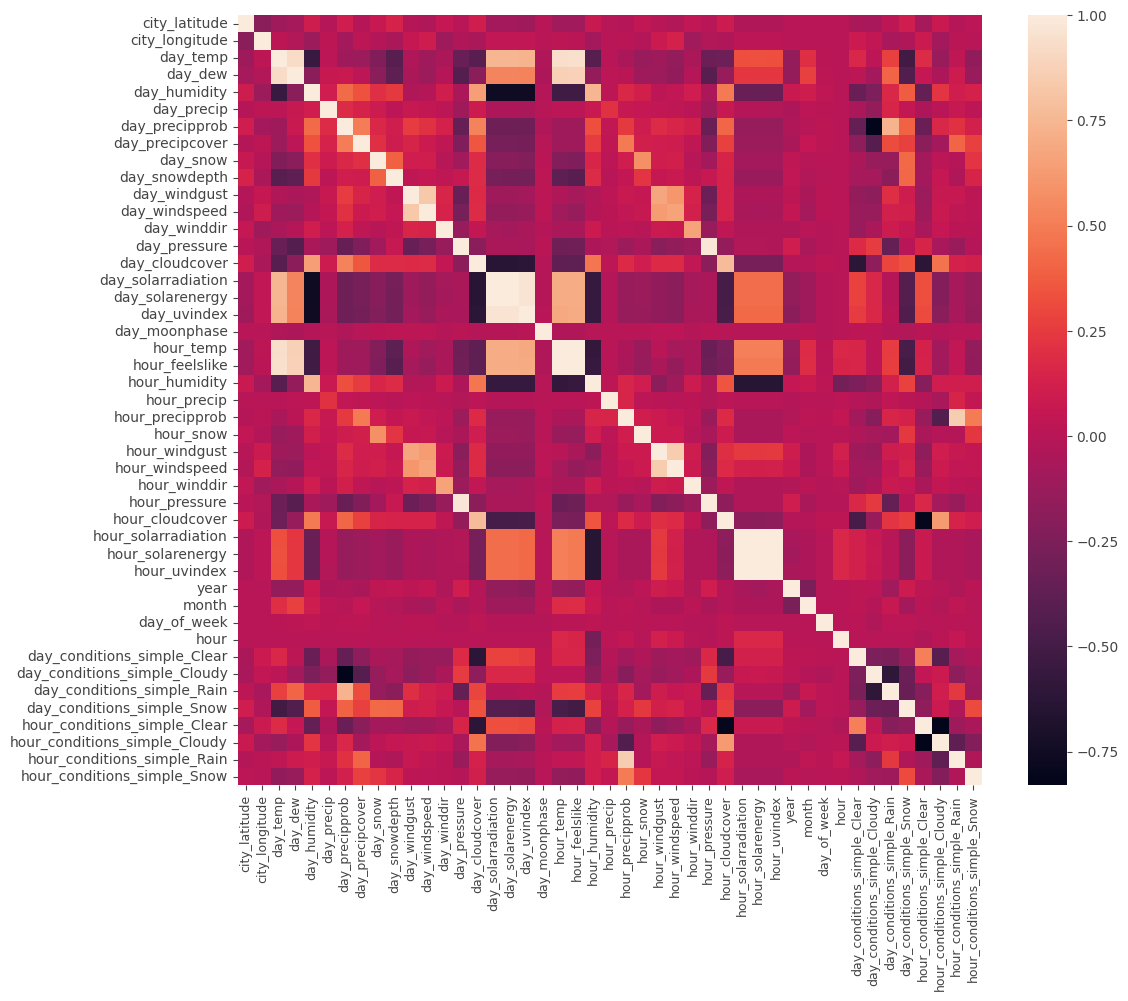

In [378]:
plt.figure(figsize=(12,10))
sns.heatmap(corr)
plt.show()

Correlation analysis was performed for all numeric weather variables. Strong correlations were observed between temperature and feels-like temperature, as well as between humidity and dew point, which is expected due to their physical relationship.

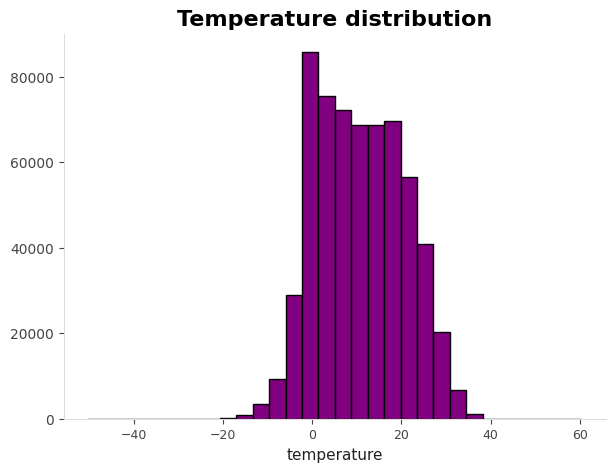

In [379]:
plt.figure(figsize=(7, 5))
plt.hist(df_weather['hour_temp'], bins=30, color='purple', edgecolor='black')
plt.title('Temperature distribution')
plt.xlabel('temperature')
plt.show()

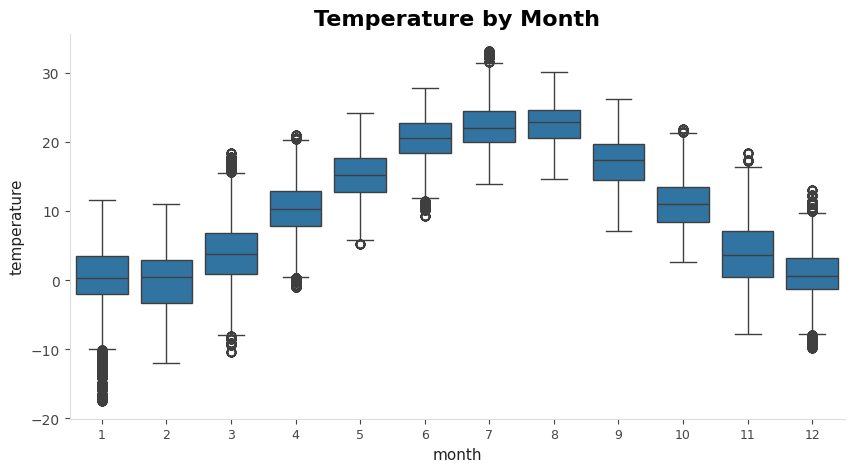

In [380]:
plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="day_temp", data=df_weather)
plt.title("Temperature by Month")
plt.ylabel('temperature')
plt.show()

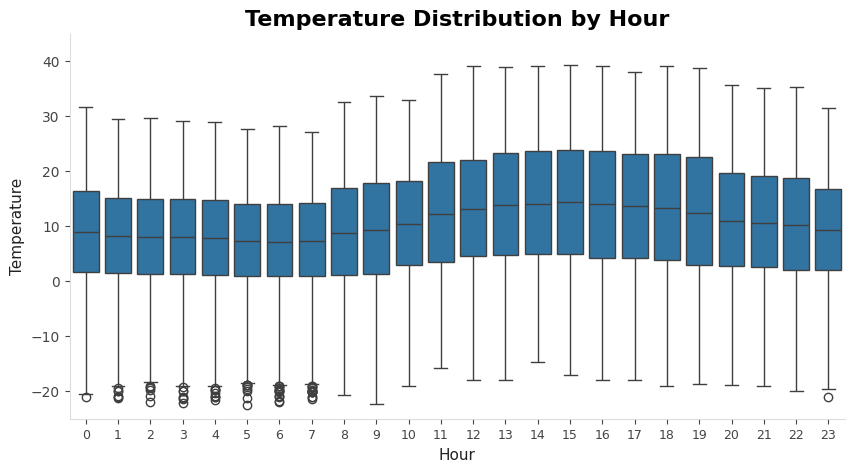

In [381]:
plt.figure(figsize=(10,5))

sns.boxplot(x="hour", y="hour_temp", data=df_weather)

plt.title("Temperature Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Temperature")

plt.xticks(range(24))
plt.ylim(-25, 45)
plt.show()

Text(0.5, 0, 'Temperature')

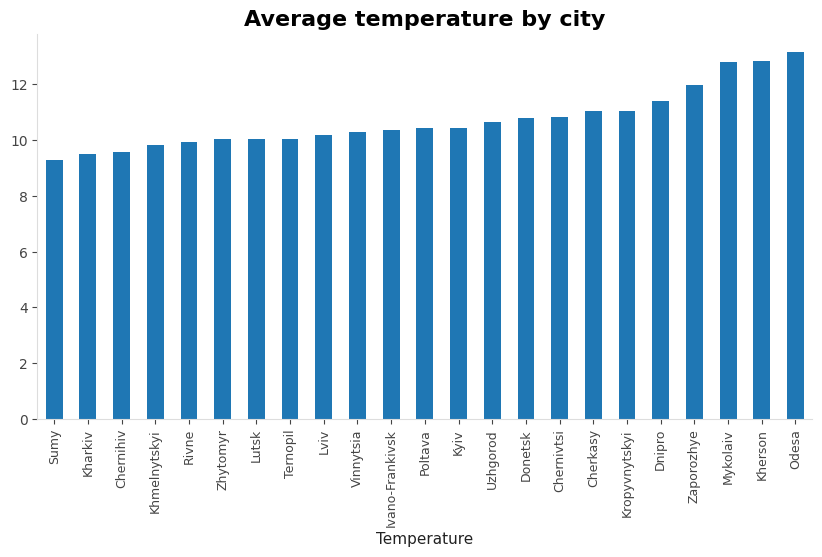

In [382]:
plt.figure(figsize=(10,5))
df_weather.groupby("city_name")["hour_temp"].mean().sort_values().plot(kind="bar")
plt.title("Average temperature by city")
plt.xlabel('Cities')
plt.xlabel('Temperature')

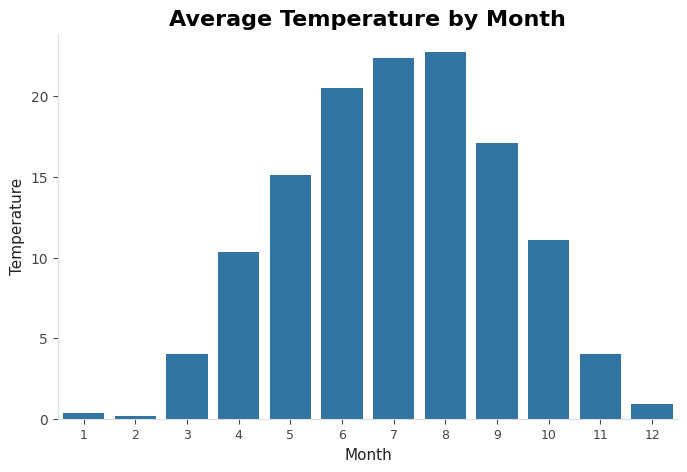

In [383]:
monthly = df_weather.groupby("month")["day_temp"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly.index, y=monthly.values)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

### War events (alarms)

In [384]:
df_war_events_raw.shape

(55788, 6)

In [385]:
df_war_events_raw.head()

,id,region_id,region_city,all_region,start,end
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


In [386]:
df_war_events_raw.sample(5)

,id,region_id,region_city,all_region,start,end
43523,145181,4,Дніпропетровська обл.,1,2024-07-18 02:35:54,2024-07-18 03:32:36
45803,147649,10,Кіровоградська обл.,1,2024-08-26 11:39:54,2024-08-26 14:26:02
24393,107780,12,Львівська обл.,1,2023-08-22 12:51:34,2023-08-22 13:23:37
48181,150232,8,Запорізька обл.,1,2024-10-05 11:49:00,2024-10-05 12:12:37
32664,133069,8,Запорізька обл.,1,2024-02-01 10:25:02,2024-02-01 12:33:32


In [387]:
df_war_events_raw.describe()

,id,region_id,all_region
count,55788.000000,55788.000000,55788.000000
mean,109103.029935,12.178121,0.972180
std,38574.559928,6.474089,0.164457
min,1.000000,1.000000,0.000000
25%,68259.750000,6.000000,1.000000
50%,126918.500000,13.000000,1.000000
75%,143399.250000,19.000000,1.000000
max,158665.000000,25.000000,1.000000


In [388]:
df_war_events_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 55788 entries, 0 to 55787
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           55788 non-null  int64
 1   region_id    55788 non-null  int64
 2   region_city  55788 non-null  str  
 3   all_region   55788 non-null  int64
 4   start        55788 non-null  str  
 5   end          55788 non-null  str  
dtypes: int64(3), str(3)
memory usage: 2.6 MB


In [389]:
print("Missing values:\n", df_war_events_raw.isna().sum())
print("\nDuplicate rows:", df_war_events_raw.duplicated().sum())
print("Duplicate id:", df_war_events_raw.duplicated(subset=["id"]).sum())

Missing values:
 id             0
region_id      0
region_city    0
all_region     0
start          0
end            0
dtype: int64

Duplicate rows: 0
Duplicate id: 0


In [390]:
df_war_events_raw[df_war_events_raw["all_region"] == 0]["region_city"].value_counts()

region_city
Київ    1552
Name: count, dtype: int64

In [391]:
df_war_events = df_war_events_raw.copy()

In [392]:
df_war_events["start"] = pd.to_datetime(df_war_events["start"], errors="coerce")
df_war_events["end"] = pd.to_datetime(df_war_events["end"], errors="coerce")

print("Invalid start dates:", df_war_events["start"].isna().sum())
print("Invalid end dates:", df_war_events["end"].isna().sum())

print(df_war_events[["start", "end"]].dtypes)

Invalid start dates: 0
Invalid end dates: 0
start    datetime64[us]
end      datetime64[us]
dtype: object


In [393]:
print("Min start:", df_war_events["start"].min())
print("Max start:", df_war_events["start"].max())

print("Min end:", df_war_events["end"].min())
print("Max end:", df_war_events["end"].max())

Min start: 2022-02-24 07:43:17
Max start: 2025-03-01 23:26:07
Min end: 2022-02-24 09:52:28
Max end: 2025-03-02 02:44:07


In [394]:
df_war_events["duration_min"] = (df_war_events["end"] - df_war_events["start"]).dt.total_seconds() / 60

print(df_war_events["duration_min"].describe())

count    55788.000000
mean        72.798103
std         93.094316
min       -781.700000
25%         26.566667
50%         39.733333
75%         84.716667
max       3031.300000
Name: duration_min, dtype: float64


In [395]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())
print("Zero durations:", (df_war_events["duration_min"] == 0).sum())

Negative durations: 1
Zero durations: 0


In [396]:
df_war_events[df_war_events["duration_min"] < 0]

,id,region_id,region_city,all_region,start,end,duration_min
47970,150000,17,Сумська обл.,1,2024-10-01 20:53:04,2024-10-01 07:51:22,-781.7


One anomalous record with a **negative duration** was found

In [397]:
df_war_events["region_key"] = (
    df_war_events["region_city"]
    .str.replace(" обл.", "")
    .replace({"Крим": "АР Крим"})
)

In [398]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [399]:
alarm_regions = sorted(df_war_events[df_war_events["all_region"] == 1]["region_key"].unique())

regions = df_regions["region"]

missing_in_alarms = sorted(set(regions) - set(alarm_regions))
extra_in_alarms = sorted(set(alarm_regions) - set(regions))

print("Missing regions in alarms:", missing_in_alarms)
print("Extra regions in alarms:", extra_in_alarms)

Missing regions in alarms: ['Луганська']
Extra regions in alarms: []


**Luhansk region is missing** in the alarms dataset.

In [400]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))
id_mismatch

Number of ID mismatches: 19


,region_id_alarms,region_key,region_id_regions
0,12,Львівська,13
1,23,Чернігівська,25
2,3,Вінницька,2
3,19,Харківська,20
4,18,Тернопільська,19
5,16,Рівненська,17
6,22,Черкаська,23
7,14,Одеська,15
9,2,Волинська,3
11,20,Херсонська,21


In [401]:
region_id_map = df_regions.set_index("region")["region_id"].to_dict()

df_war_events["region_id"] = df_war_events["region_key"].map(region_id_map)
df_war_events.loc[df_war_events["region_key"] == "Київ", "region_id"] = 26

print("Missing region_id after remapping:", df_war_events["region_id"].isna().sum())
print(df_war_events[["region_city", "region_key", "region_id"]].sample(10))

Missing region_id after remapping: 0
                 region_city        region_key  region_id
16732          Донецька обл.          Донецька        5.0
48580         Черкаська обл.         Черкаська       23.0
12985          Донецька обл.          Донецька        5.0
19757        Запорізька обл.        Запорізька        8.0
16943          Донецька обл.          Донецька        5.0
47641  Дніпропетровська обл.  Дніпропетровська        4.0
15984           Одеська обл.           Одеська       15.0
47243          Донецька обл.          Донецька        5.0
40661  Дніпропетровська обл.  Дніпропетровська        4.0
41112                   Київ              Київ       26.0


In [402]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))

Number of ID mismatches: 0


In [403]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_DARK = "#1D4E89"
BLUE_MAIN = "#2F6DB3"
BLUE_SOFT = "#A9C6E8"
BLUE_LIGHT = "#DCEAF7"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)

def add_subtitle(fig, text):
    fig.text(0.125, 0.92, text, fontsize=10, color=TEXT_GREY)

In [404]:
df_plot = df_war_events.copy()

df_plot = df_plot[df_plot["duration_min"] > 0].copy() # keep only valid rows

df_plot["year_month"] = df_plot["start"].dt.to_period("M")
df_plot["hour"] = df_plot["start"].dt.hour
df_plot["weekday"] = df_plot["start"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

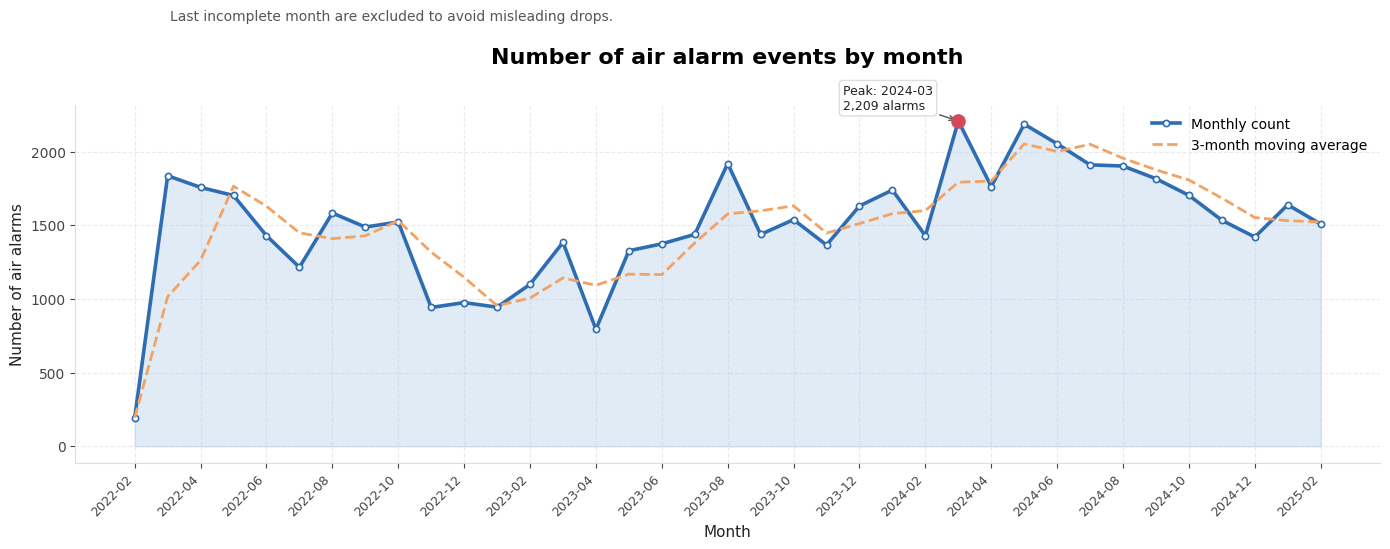

In [405]:
monthly_counts = df_plot.groupby("year_month").size().sort_index()
monthly_counts_plot = monthly_counts.iloc[:-1]

x_labels = monthly_counts_plot.index.astype(str).tolist()
y_values = monthly_counts_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_counts_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Monthly count"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)

ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} alarms",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(x[peak_idx] - 3.5, y_values[peak_idx] + 80),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY),
    fontsize=9,
    color="#222222",
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_title("Number of air alarm events by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Number of air alarms")

ax.legend(frameon=False)

style_ax(ax, "both")
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

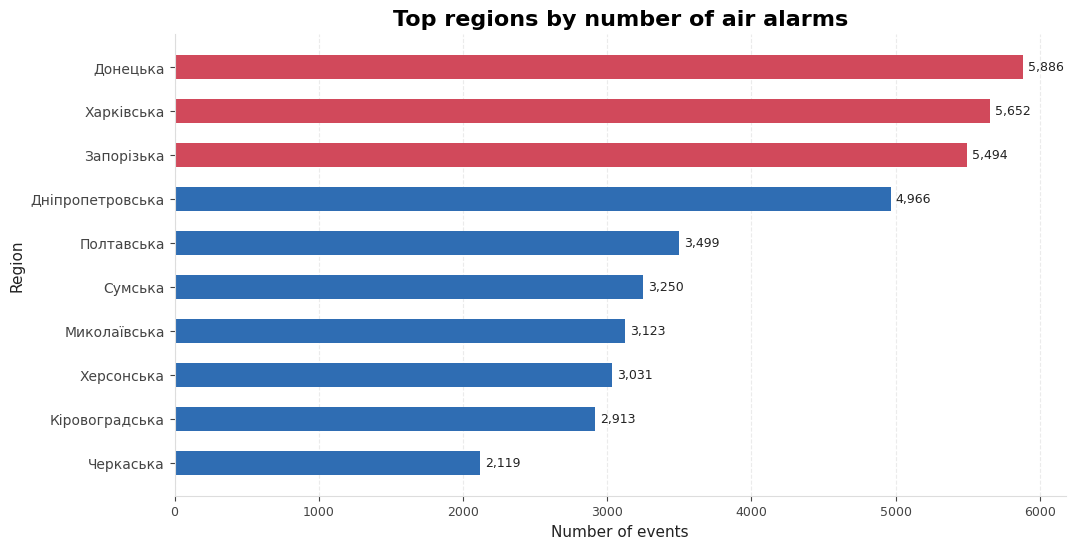

In [406]:
region_counts = df_plot.groupby("region_key").size().sort_values(ascending=False).head(10)

plot_region_counts = region_counts.sort_values()
top3_regions = set(region_counts.head(3).index)

bar_colors = [
    RED_ACCENT if region in top3_regions 
    else BLUE_MAIN for region in plot_region_counts.index
]

fig, ax = plt.subplots(figsize=(11.5, 6))

bars = ax.barh(
    plot_region_counts.index,
    plot_region_counts.values,
    color=bar_colors,
    height=0.55
)

for bar, value in zip(bars, plot_region_counts.values):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9,
        color="#222222"
    )

ax.set_title("Top regions by number of air alarms")
ax.set_xlabel("Number of events")
ax.set_ylabel("Region")
style_ax(ax, "x")
plt.show()

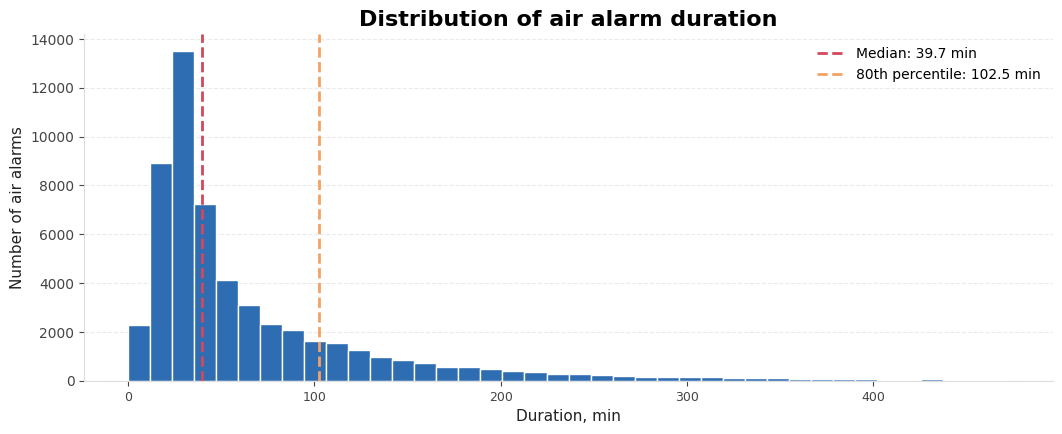

In [407]:
duration_min = df_plot["duration_min"].copy()
p99 = duration_min.quantile(0.99)
p80 = duration_min.quantile(0.80)
median_val = duration_min.median()

dur_clipped = duration_min[duration_min <= p99]

fig, ax = plt.subplots(figsize=(12.5, 4.5))

ax.hist(
    dur_clipped,
    bins=40,
    color=BLUE_MAIN,
    edgecolor="white"
)

ax.axvline(median_val, color=RED_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_val:.1f} min")
ax.axvline(p80, color=GOLD, linestyle="--", linewidth=2, label=f"80th percentile: {p80:.1f} min")

ax.set_title("Distribution of air alarm duration")
ax.set_xlabel("Duration, min")
ax.set_ylabel("Number of air alarms")
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")
plt.show()

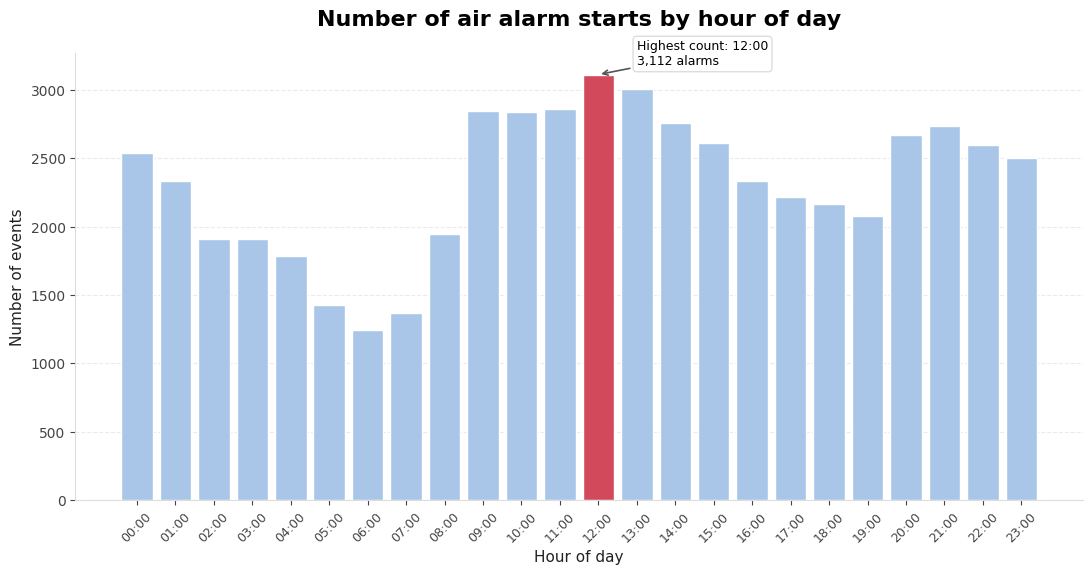

In [408]:
hour_counts = df_plot.groupby("hour").size()

top_hour = hour_counts.idxmax()
hour_colors = [BLUE_SOFT] * 24
hour_colors[top_hour] = RED_ACCENT

fig, ax = plt.subplots(figsize=(13, 5.8))
bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="white",
    width=0.82
)

ax.annotate(
    f"Highest count: {top_hour:02d}:00\n{hour_counts[top_hour]:,} alarms",
    xy=(top_hour, hour_counts[top_hour]),
    xytext=(top_hour + 1, hour_counts[top_hour] + 70),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY, lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title("Number of air alarm starts by hour of day", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of events")
style_ax(ax, "y")
plt.show()

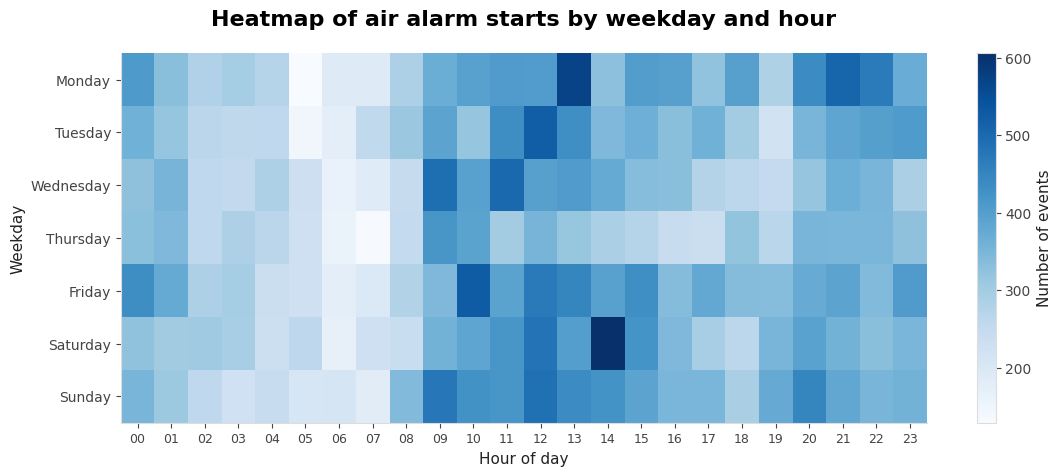

In [409]:
heatmap_data = (
    df_plot.groupby(["weekday", "hour"]).size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Heatmap of air alarm starts by weekday and hour", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of events")
plt.show()

### ISW

In [410]:
df_isw_raw.shape

(1467, 4)

In [411]:
df_isw_raw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [412]:
df_isw_raw.sample(5)

,date,title,url,text
921,2024-09-02,"Russian Offensive Campaign Assessment, Septemb...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
1070,2025-01-29,"Russian Offensive Campaign Assessment, January...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
1001,2024-11-21,"Russian Offensive Campaign Assessment, Novembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
830,2024-06-03,"Russian Offensive Campaign Assessment, June 3,...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
1402,2025-12-27,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [413]:
df_isw_raw.describe()

,date,title,url,text
count,1467,1467,1467,1467
unique,1467,1455,1455,1455
top,2022-02-24,None,None,None
freq,1,13,13,13


In [414]:
df_isw_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    1467 non-null   str  
 1   title   1467 non-null   str  
 2   url     1467 non-null   str  
 3   text    1467 non-null   str  
dtypes: str(4)
memory usage: 46.0 KB


All columns currently have the `object` data type. 

In [415]:
df_isw = df_isw_raw.copy()

In [416]:
for col in ["date","title", "url", "text"]:
    df_isw[col] = df_isw[col].replace("None", np.nan)

In [417]:
df_isw["date"] = pd.to_datetime(df_isw["date"], errors="coerce")
print("Invalid dates:", df_isw["date"].isna().sum())
print(df_isw["date"].dtype)

Invalid dates: 0
datetime64[us]


In [418]:
outside_range = df_isw[(df_isw["date"] < "2022-02-24") | (df_isw["date"] > "2026-03-01")]
print(outside_range)

Empty DataFrame
Columns: [date, title, url, text]
Index: []


In [419]:
print("Missing values:", df_isw.isna().sum())

Missing values: date      0
title    13
url      13
text     13
dtype: int64


In [420]:
print("Duplicate dates:", df_isw["date"].duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].dropna().duplicated().sum())
print("Duplicate non-missing urls:", df_isw["url"].dropna().duplicated().sum())
print("Duplicate non-missing text:", df_isw["text"].dropna().duplicated().sum())
print("Duplicate full rows:", df_isw.duplicated().sum())

Duplicate dates: 0
Duplicate non-missing titles: 0
Duplicate non-missing urls: 0
Duplicate non-missing text: 0
Duplicate full rows: 0


In [421]:
dup_dates = df_isw[df_isw["date"].duplicated(keep=False)]
dup_dates[["date", "title", "url"]]

,date,title,url


In [422]:
df_isw = df_isw.dropna(subset=["title", "url", "text"]).copy()

In [423]:
print("Missing values:", df_isw.isna().sum())

Missing values: date     0
title    0
url      0
text     0
dtype: int64


In [424]:
def clean_isw_text(text):
    text = str(text)
    text = text.replace("Previous\nNext", " ")
    text = text.replace("Click\nhere", " ")
    text = text.replace("\n", " ")
    return text

df_isw["text_clean"] = df_isw["text"].apply(clean_isw_text)

In [425]:
df_isw["text"] = df_isw["text_clean"]
df_isw = df_isw.drop(columns=["text_clean"])

In [426]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [427]:
df_isw_plot = df_isw.copy()

df_isw_plot["year"] = df_isw_plot["date"].dt.year
df_isw_plot["year_month"] = df_isw_plot["date"].dt.to_period("M")
df_isw_plot["word_count"] = df_isw_plot["text"].str.split().str.len()
df_isw_plot["char_count"] = df_isw_plot["text"].str.len()

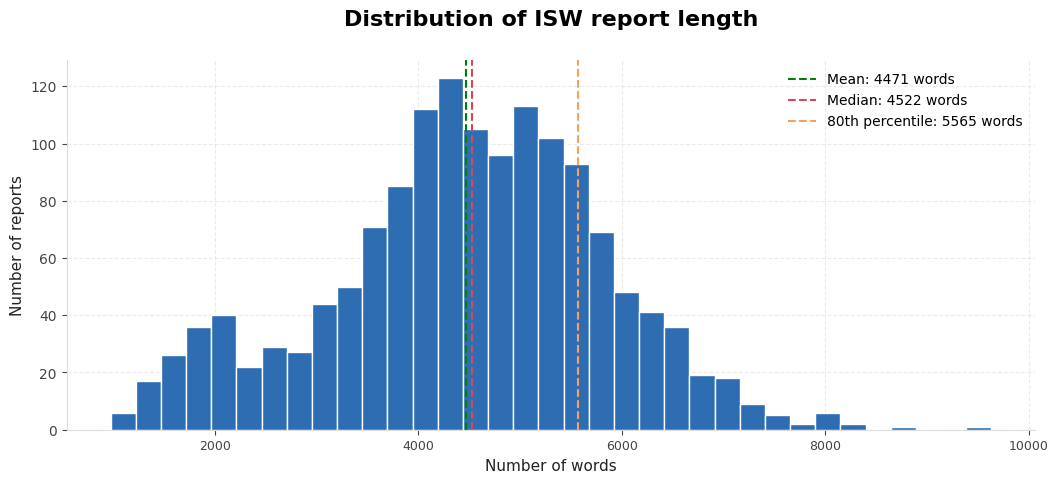

In [428]:
word_count = df_isw_plot["word_count"].copy()

p80 = word_count.quantile(0.80)
median_val = word_count.median()
mean_val = word_count.mean()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(word_count, bins=35, color=BLUE_MAIN,edgecolor="white")

ax.axvline(
    mean_val,
    color="green",
    linestyle="--",
    label=f"Mean: {mean_val:.0f} words"
)
ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} words"
)
ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} words"
)

ax.set_title("Distribution of ISW report length", pad=25)
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of reports")
style_ax(ax, "both")
ax.legend(frameon=False, loc="upper right")
plt.show()

Distribution is not perfectly symmetric and appears to have tails on both sides, with most reports concentrated between roughly 4000 and 5500 words. 80% of reports are shorter than 5565 words.

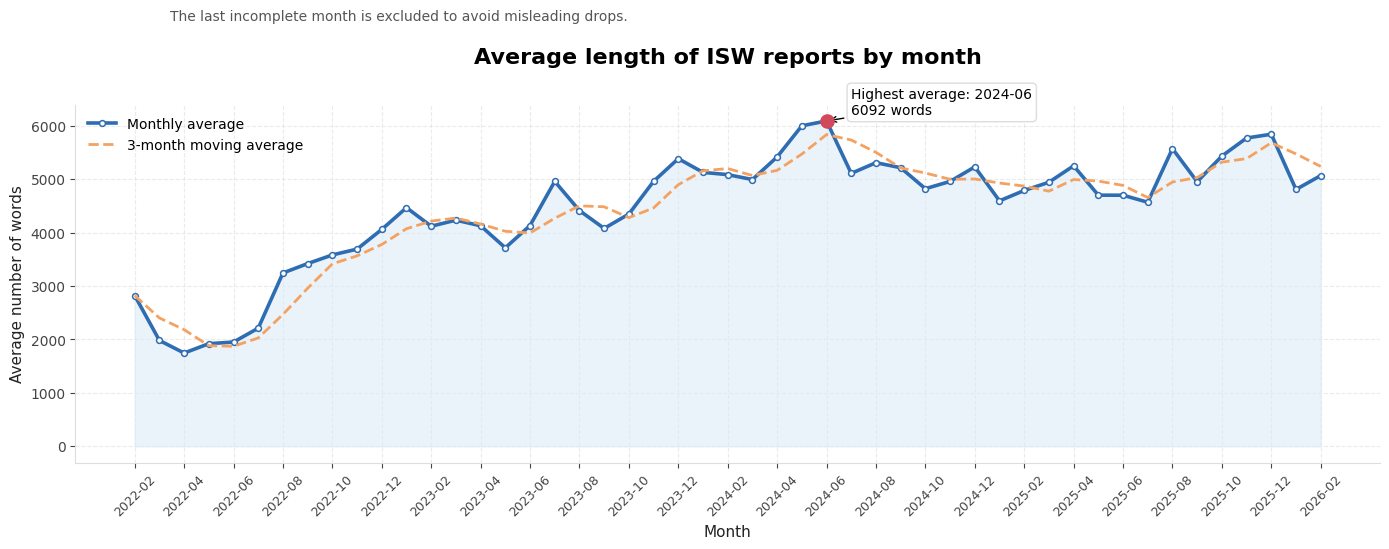

In [429]:
monthly_avg_words = df_isw_plot.groupby("year_month")["word_count"].mean().sort_index()
monthly_avg_words_plot = monthly_avg_words.iloc[:-1]

x_labels = monthly_avg_words_plot.index.astype(str).tolist()
y_values = monthly_avg_words_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_avg_words_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_LIGHT, alpha=0.55)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.2,
    markerfacecolor="white",
    markeredgewidth=1.1,
    label="Monthly average"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Highest average: {x_labels[peak_idx]}\n{y_values[peak_idx]:.0f} words",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] + 1), y_values[peak_idx] + 120),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Average length of ISW reports by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Average number of words")

ax.legend(frameon=False)
style_ax(ax, "both")
add_subtitle(fig, "The last incomplete month is excluded to avoid misleading drops.")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Line chart shows that the average report length was lower in 2022 and became higher and more stable in later periods.

### Telegram 

In [430]:
df_tg_raw.shape

(129477, 3)

In [431]:
df_tg_raw.head()

,date,channel,message
0,2026-03-06 11:06:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
1,2026-03-06 10:57:29+00:00,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...
2,2026-03-06 06:32:47+00:00,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...
3,2026-03-05 14:46:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
4,2026-03-05 13:46:39+00:00,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...


In [432]:
df_tg_raw.sample(5)

,date,channel,message
22857,2025-03-02 15:55:08+00:00,UkraineNow,**Трамп і його команда відновлять діалог з укр...
103396,2025-01-15 05:18:17+00:00,kpszsu,"Групи КР на межі Житомирщини і Вінниччини, кур..."
117674,2024-03-28 21:48:22+00:00,kpszsu,Ракета на Кам'янське!
40129,2024-01-15 13:05:32+00:00,UkraineNow,**Повітряна тривога - активність ворожої такти...
86754,2025-10-02 18:12:28+00:00,kpszsu,🛵 БпЛА в напрямку Полтави.


In [433]:
df_tg_raw.describe()

,date,channel,message
count,129477,129477,129477
unique,129333,3,107432
top,2025-10-23 03:28:04+00:00,UkraineNow,📢 Відбій загрози.
freq,6,61363,929


In [434]:
df_tg_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 129477 entries, 0 to 129476
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   date     129477 non-null  str  
 1   channel  129477 non-null  str  
 2   message  129477 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


In [435]:
print("Unique channels:", df_tg_raw["channel"].nunique())
print(df_tg_raw["channel"].value_counts())

Unique channels: 3
channel
UkraineNow     61363
kpszsu         56272
DeepStateUA    11842
Name: count, dtype: int64


In [436]:
print("Duplicate rows:",
      df_tg_raw.duplicated(subset=["date", "channel", "message"]).sum())

print("Duplicate messages:",
      df_tg_raw.duplicated(subset=["message"]).sum())

Duplicate rows: 0
Duplicate messages: 22045


In [437]:
df_tg = df_tg_raw.copy()

In [438]:
df_tg["date"] = pd.to_datetime(df_tg["date"], utc=True, errors="coerce")
df_tg["date"] = df_tg["date"].dt.tz_convert("Europe/Kyiv")
df_tg["date"] = df_tg["date"].dt.tz_localize(None)

print("Invalid dates:", df_tg["date"].isna().sum())
print(df_tg["date"].dtype)

Invalid dates: 0
datetime64[us]


In [439]:
print("Min date:", df_tg["date"].min())
print("Max date:", df_tg["date"].max())

Min date: 2022-02-24 05:51:12
Max date: 2026-03-06 18:49:21


In [440]:
df_tg["message"] = df_tg["message"].astype(str)

print("Empty messages:", (df_tg["message"] == "").sum())
print("Whitespace messages:", df_tg["message"].str.strip().eq("").sum())

print("\nShortest messages:")
print(df_tg.loc[df_tg["message"].str.len().nsmallest(10).index, ["channel", "date", "message"]])

Empty messages: 0
Whitespace messages: 0

Shortest messages:
           channel                date message
1218   DeepStateUA 2025-06-01 14:49:49       🕸
4052   DeepStateUA 2024-02-16 14:20:06       🥪
7472   DeepStateUA 2022-11-11 13:10:16       🍉
9531   DeepStateUA 2022-04-12 21:46:52       😎
9804   DeepStateUA 2022-04-01 07:39:05       😳
10044  DeepStateUA 2022-03-22 18:42:05       💸
10163  DeepStateUA 2022-03-17 23:02:54       😐
10670  DeepStateUA 2022-03-04 18:47:06       🤨
10683  DeepStateUA 2022-03-04 14:53:13       🍾
10798  DeepStateUA 2022-03-03 09:02:20       🔴


In [441]:
CHANNEL_COLORS = {
    "UkraineNow": "green" ,
    "kpszsu": GOLD,
    "DeepStateUA": BLUE_DARK
}

In [442]:
df_tg["time"] = df_tg["date"].dt.strftime("%H:%M:%S")
df_tg["hour"] = df_tg["date"].dt.hour
df_tg["year_month"] = df_tg["date"].dt.to_period("M")
df_tg["date_day"] = df_tg["date"].dt.floor("D")

In [443]:
df_tg

,date,channel,message,time,hour,year_month,date_day
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05
...,...,...,...,...,...,...,...
129472,2022-02-25 09:45:10,kpszsu,Вибухи на аеродромі Міллєрово в Ростовській об...,09:45:10,9,2022-02,2022-02-25
129473,2022-02-25 09:43:53,kpszsu,🛩🛩🛩🛩\nДо строю авіації Повітряних Сил Збройних...,09:43:53,9,2022-02,2022-02-25
129474,2022-02-25 00:43:47,kpszsu,ПОВІТРЯНІ СИЛИ ЗАВДАЛИ ВОРОГУ СУТТЄВИХ ВТРАТ\n...,00:43:47,0,2022-02,2022-02-25
129475,2022-02-25 00:43:23,kpszsu,https://fb.watch/bnMUkUvwfp/,00:43:23,0,2022-02,2022-02-25


In [444]:
df_tg_plot = df_tg.copy()

In [445]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
df_tg_plot["weekday"] = pd.Categorical(
    df_tg_plot["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

df_tg_plot["message_len"] = df_tg_plot["message"].str.len()
df_tg_plot["word_count"] = df_tg_plot["message"].str.split().str.len()
df_tg_plot["is_duplicate_message"] = df_tg_plot.duplicated(subset=["message"], keep=False)

df_tg_plot.head()

,date,channel,message,time,hour,year_month,date_day,weekday,message_len,word_count,is_duplicate_message
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06,Friday,606,42,False
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06,Friday,1171,116,False
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06,Friday,1477,140,False
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05,Thursday,669,44,False
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05,Thursday,1740,208,False


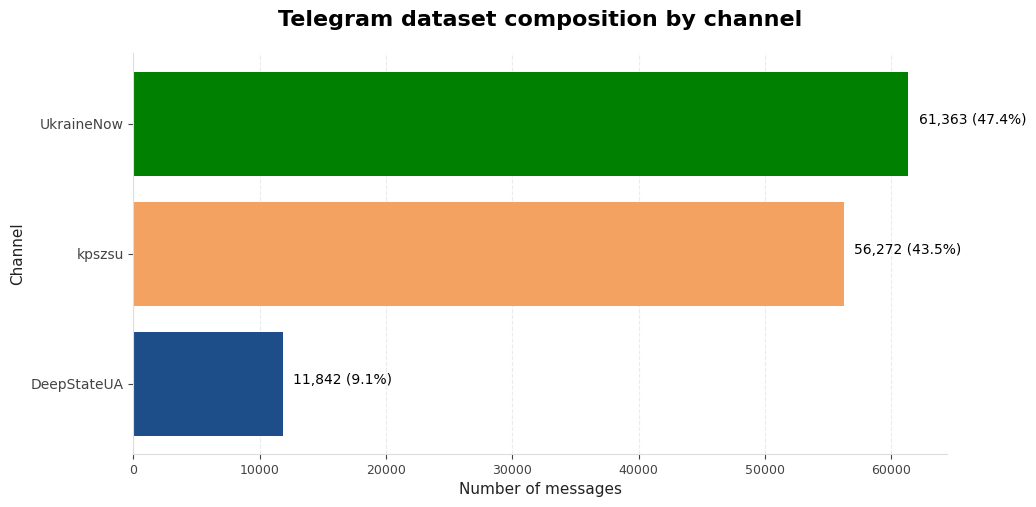

In [446]:
channel_counts = df_tg_plot["channel"].value_counts().sort_values()
channel_counts_percent = channel_counts / channel_counts.sum() * 100 

bar_colors = [CHANNEL_COLORS[channel] for channel in channel_counts.index]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.barh(
    channel_counts.index,
    channel_counts.values,
    color=bar_colors,
)

for bar, count, share in zip(bars, channel_counts.values, channel_counts_percent.values):
    ax.text(
        count + 800,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({share:.1f}%)",
        fontsize=10
    )

ax.set_title("Telegram dataset composition by channel", pad=20)
ax.set_xlabel("Number of messages")
ax.set_ylabel("Channel")
style_ax(ax, "x")
plt.show()

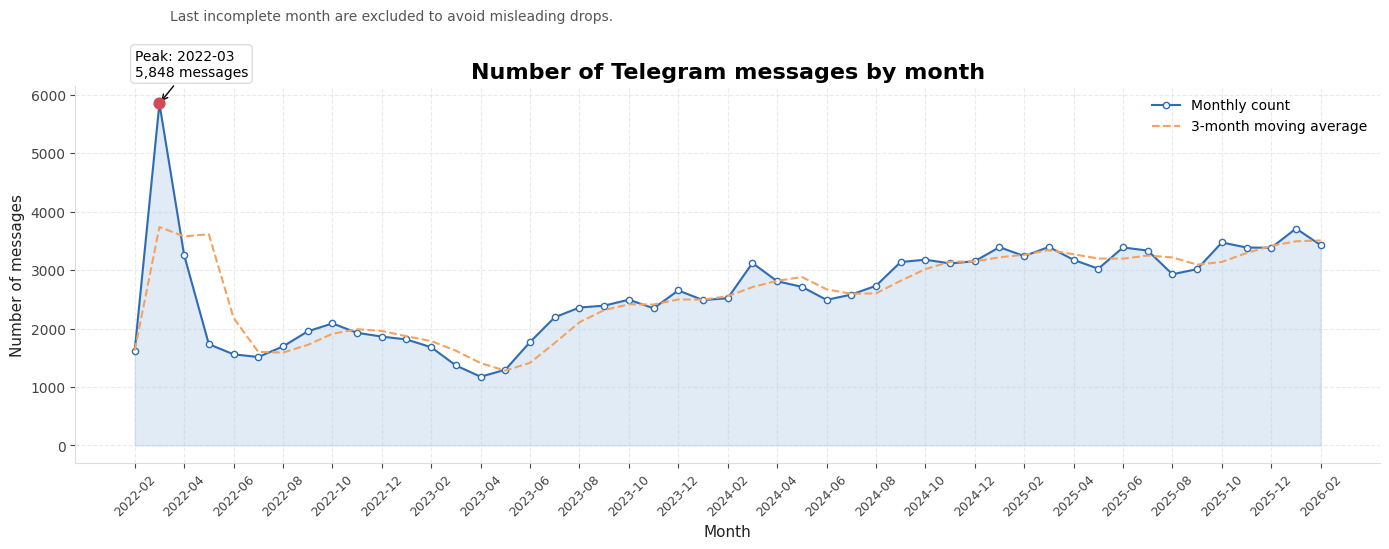

In [447]:
monthly_total = (df_tg_plot.groupby("year_month").size())

last_day = df_tg_plot["date"].max()
last_month_complete = last_day.day == last_day.days_in_month
if last_month_complete:
    monthly_total_plot = monthly_total.copy()
else:
    monthly_total_plot = monthly_total.iloc[:-1]

x_labels = monthly_total_plot.index.astype(str).tolist()
y_values = monthly_total_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_total_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    label="Monthly count"
)
ax.plot(
    x, moving_avg,
    color=GOLD,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=60, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} messages",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] - 4), y_values[peak_idx] + y_values.max() * 0.08),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Number of Telegram messages by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False)
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")
style_ax(ax, "both")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

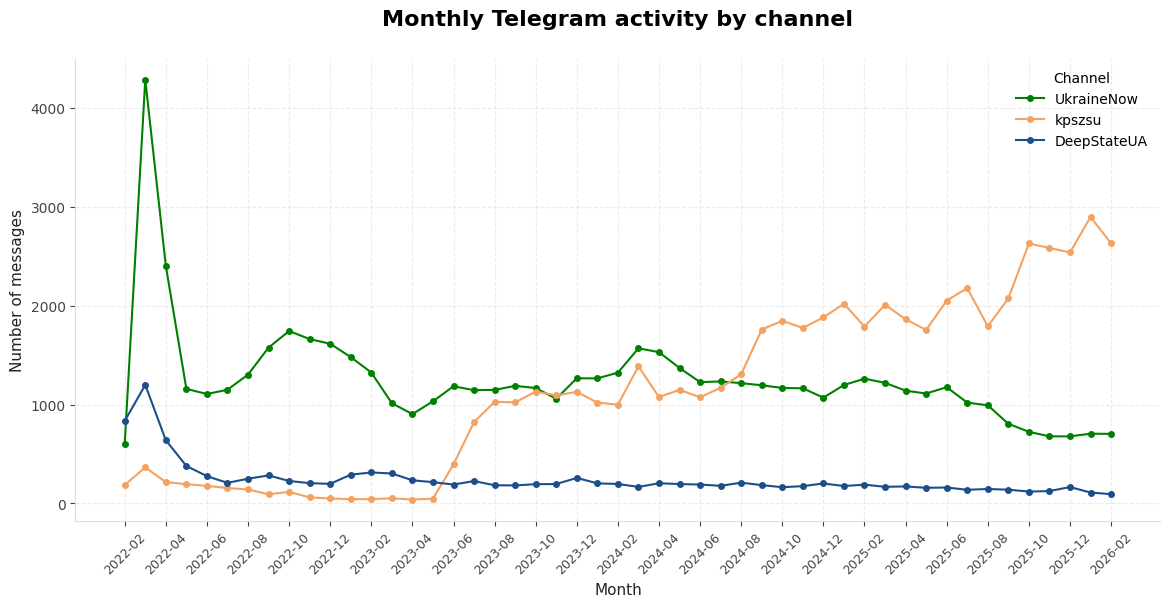

In [448]:
monthly_by_channel = (
    df_tg_plot.groupby(["year_month", "channel"])
    .size()
    .reset_index(name="messages_count")
)

if not last_month_complete:
    monthly_by_channel = monthly_by_channel[
        monthly_by_channel["year_month"] != monthly_by_channel["year_month"].max()
    ].copy()

monthly_by_channel["year_month_str"] = monthly_by_channel["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for channel in ["UkraineNow", "kpszsu", "DeepStateUA"]:
    temp = monthly_by_channel[monthly_by_channel["channel"] == channel]
    ax.plot(
        temp["year_month_str"],
        temp["messages_count"],
        label=channel,
        color=CHANNEL_COLORS[channel],
        marker="o",
        markersize=4
    )

tick_idx = np.arange(0, monthly_by_channel["year_month_str"].nunique(), 2)
unique_months = monthly_by_channel["year_month_str"].drop_duplicates().tolist()

ax.set_xticks(tick_idx)
ax.set_xticklabels([unique_months[i] for i in tick_idx], rotation=45)
ax.set_title("Monthly Telegram activity by channel", pad=24)
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(title="Channel", frameon=False)
style_ax(ax, "both")
plt.show()

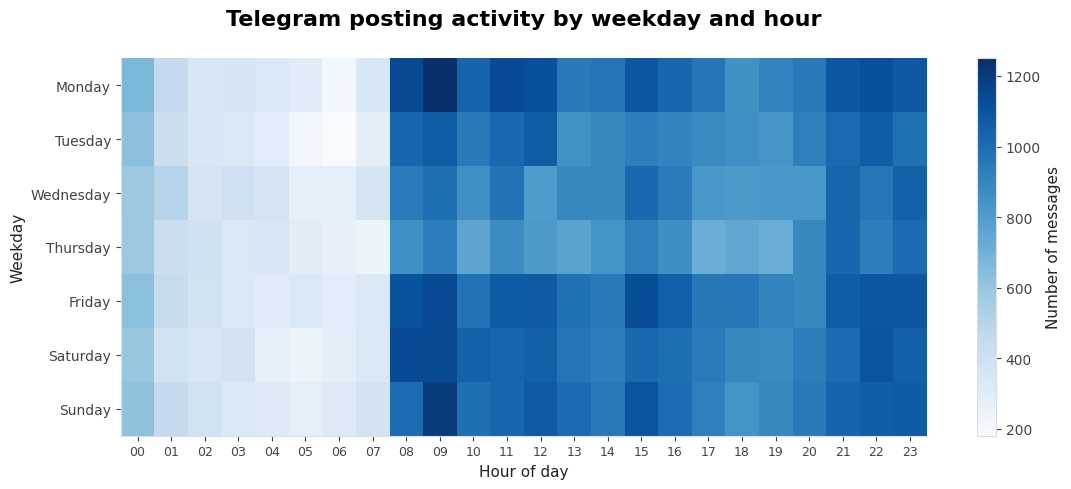

In [449]:
heatmap_data = (
    df_tg_plot.groupby(["weekday", "hour"])
    .size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.9))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Telegram posting activity by weekday and hour", pad=24)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of messages")
plt.show()

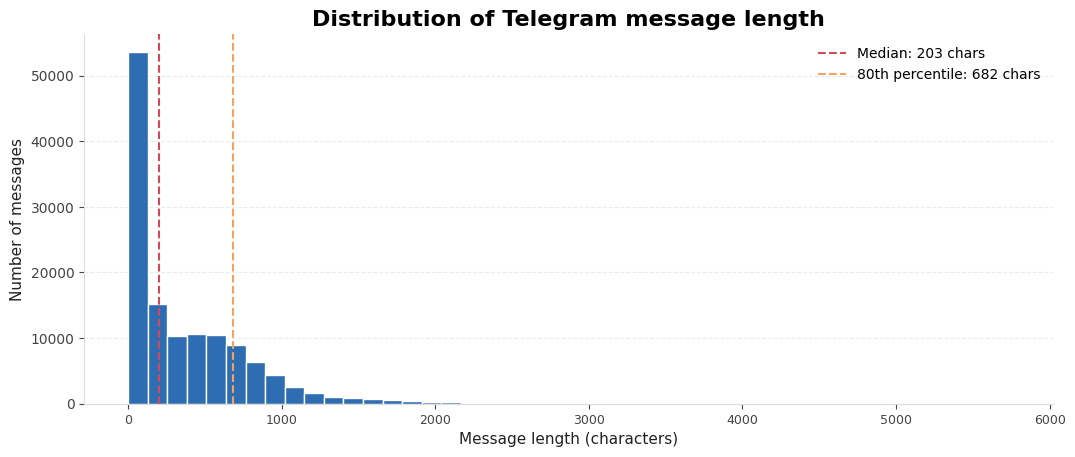

In [450]:
message_len = df_tg_plot["message_len"].copy()

p80 = message_len.quantile(0.80)
median_val = message_len.median()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(
    message_len,
    bins=45,
    color=BLUE_MAIN,
    edgecolor="white",
)

ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} chars"
)

ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} chars"
)

ax.set_title("Distribution of Telegram message length")
ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False, loc="upper right")
style_ax(ax, "y")
plt.show()

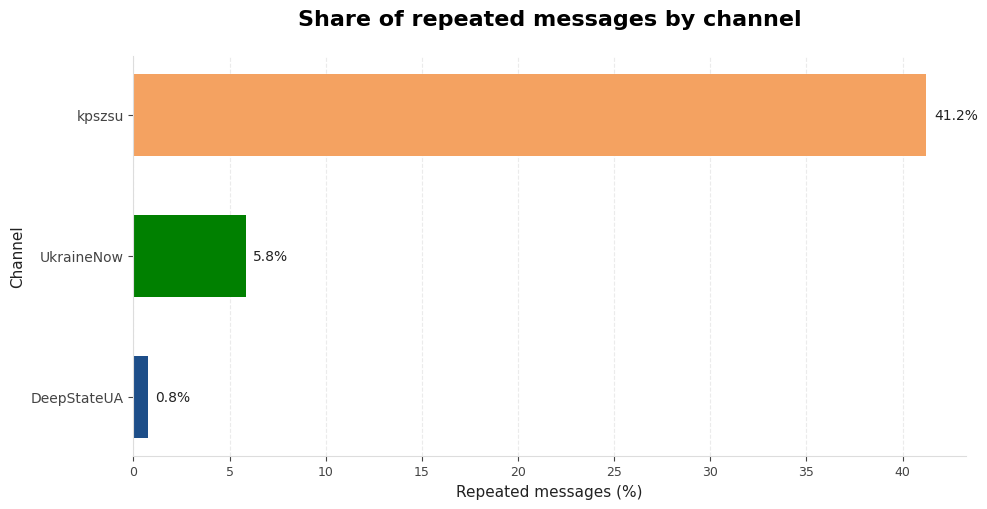

In [451]:
dup_share = (
    df_tg_plot.groupby("channel")["is_duplicate_message"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5.2))

bars = ax.barh(
    dup_share.index,
    dup_share.values,
    color=[CHANNEL_COLORS[ch] for ch in dup_share.index],
    height=0.58
)

for bar, value in zip(bars, dup_share.values):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        color="#222222"
    )

ax.set_title("Share of repeated messages by channel", pad=22)
ax.set_xlabel("Repeated messages (%)")
ax.set_ylabel("Channel")

style_ax(ax, "x")
plt.tight_layout()
plt.show()

## IV. Prepare data

### ISW

In [452]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [453]:
df_isw['text'] = df_isw['text'].str.lower()

In [454]:
df_isw['text'] = df_isw['text'].str.replace(f"[{string.punctuation}]", "", regex=True)

1. Підготовка

In [455]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
isw_word_cache = {}

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\slava\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [456]:
def smart_preprocess_cached(text):
    text = str(text).lower()

    # Очистка
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b(?:https|http|www)\S*\b', ' ', text)  #поламані URL

    text = re.sub(r'\b(?:twitter|facebook|telegram|youtube|instagram|isw)\S*\b', ' ', text)
    text = re.sub(r'\b(previous|next|click here|dot)\b', ' ', text)
    text = re.sub(r'[^a-z\s-]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)

    words = text.split()
    clean_words = []

    for w in words:
        # ПЕРЕВІРКА СТОП-СЛІВ
        if w in stop_words or len(w) <= 2:
            continue

        # КЕШУВАННЯ ЛЕМАТИЗАЦІЇ
        if w not in isw_word_cache:
            isw_word_cache[w] = lemmatizer.lemmatize(w)

        clean_words.append(isw_word_cache[w])

    return " ".join(clean_words)

2. Застосування

In [457]:
tqdm.pandas()
print("ISW word processing...")
df_isw['text_final'] = df_isw['text'].progress_apply(smart_preprocess_cached)

ISW word processing...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1454/1454 [00:09<00:00, 150.50it/s]


3. PCA

In [458]:
from sklearn.decomposition import TruncatedSVD

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5)
X_sparse = vectorizer.fit_transform(df_isw['text_final'])

svd = TruncatedSVD(n_components=150, random_state=42)
X_reduced = svd.fit_transform(X_sparse)

df_isw_features = pd.DataFrame(
    X_reduced, 
    columns=[f'isw_topic_{i}' for i in range(150)]
)

df_isw_final = pd.concat([df_isw[['date']].reset_index(drop=True), df_isw_features], axis=1)
df_isw_final.to_csv("isw_processed_svd.csv", index=False, encoding="utf-8-sig")

In [459]:
vocab = vectorizer.get_feature_names_out()
components = svd.components_

topic_dict = {}
for i, comp in enumerate(components):
    top_indices = comp.argsort()[-10:][::-1]
    top_words = [vocab[idx] for idx in top_indices]
    topic_dict[f"isw_topic_{i}"] = ", ".join(top_words)

for topic, words in list(topic_dict.items())[:10]:
    print(f"{topic}: {words}")

isw_topic_0: russian, force, ukrainian, russian force, near, oblast, ukraine, military, claimed, effort
isw_topic_1: near, pokrovsk, drone, direction, motorized, motorized rifle, order battle, advanced, rifle, caa
isw_topic_2: force, izyum, russian force, mariupol, ukrainian, severodonetsk, city, toward, slovyansk, kharkiv
isw_topic_3: april, march, ukraine, russia, effort, april russian, march russian, mariupol, february, izyum
isw_topic_4: january, december, january russian, february, reported january, january ukrainian, november, december russian, published january, hulyaipole
isw_topic_5: january, july, august, june, january russian, reported january, july russian, january ukrainian, prigozhin, wagner
isw_topic_6: december, november, december russian, july, june, reported december, december ukrainian, published december, november russian, claimed december
isw_topic_7: march, august, december, february, september, march russian, prigozhin, wagner, bakhmut, august russian
isw_topic_8

4. Результати

In [460]:
print(f"Розмірність матриці: {X.shape}")
feature_names = vectorizer.get_feature_names_out()
print("The first 20 features")
print(feature_names[:20])

Розмірність матриці: (1454, 5000)
The first 20 features
['abandon' 'abandoned' 'ability' 'able' 'abroad' 'accept' 'access'
 'access archive' 'accession' 'according' 'account' 'accumulating'
 'accusation' 'accused' 'accusing' 'achieve' 'achieved' 'achieving'
 'acknowledged' 'across']


5. EDA

In [461]:
all_words = " ".join(df_isw['text_final']).split()
word_counts = Counter(all_words)

print("20 most common words:", word_counts.most_common(20))

20 most common words: [('russian', 224315), ('force', 108639), ('ukrainian', 92638), ('near', 46392), ('ukraine', 41174), ('oblast', 40625), ('military', 32957), ('claimed', 31371), ('russia', 30070), ('effort', 28087), ('reported', 24633), ('operation', 23197), ('area', 22841), ('drone', 20366), ('continued', 18188), ('offensive', 17850), ('city', 16620), ('direction', 16607), ('stated', 16143), ('reportedly', 15427)]


In [462]:
df_isw['doc_length'] = df_isw['text_final'].apply(lambda x: len(x.split()))

print("Document duration statistics:")
print(df_isw['doc_length'].describe())

Document duration statistics:
count    1454.000000
mean     2707.194635
std       820.394181
min       601.000000
25%      2246.250000
50%      2747.000000
75%      3261.000000
max      5741.000000
Name: doc_length, dtype: float64


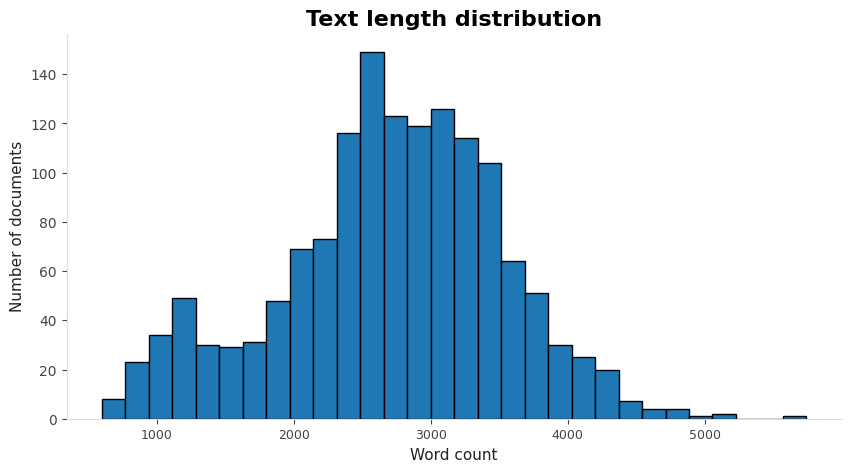

In [463]:
plt.figure(figsize=(10,5))
plt.hist(df_isw['doc_length'], bins=30, edgecolor='black')
plt.title("Text length distribution")
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.show()

In [464]:
doc_count = {}
for text in df_isw['text_final']:
    tokens = set(text.split()) 
    for token in tokens:
        doc_count[token] = doc_count.get(token, 0) + 1

total_docs = len(df_isw)
top_doc_words = sorted(doc_count.items(), key=lambda x: x[1], reverse=True)[:20]

print("\n Top-20 most popular words(ISW):")
for token, count in top_doc_words:
    print(f"{token}: {count}/{total_docs} = {count/total_docs:.2%}")


 Top-20 most popular words(ISW):
operation: 1454/1454 = 100.00%
ukrainian: 1454/1454 = 100.00%
campaign: 1454/1454 = 100.00%
ukraine: 1454/1454 = 100.00%
russian: 1454/1454 = 100.00%
offensive: 1454/1454 = 100.00%
oblast: 1454/1454 = 100.00%
force: 1454/1454 = 100.00%
assessment: 1454/1454 = 100.00%
reported: 1453/1454 = 99.93%
russia: 1453/1454 = 99.93%
key: 1453/1454 = 99.93%
military: 1453/1454 = 99.93%
effort: 1452/1454 = 99.86%
report: 1451/1454 = 99.79%
continued: 1451/1454 = 99.79%
city: 1450/1454 = 99.72%
western: 1449/1454 = 99.66%
continue: 1449/1454 = 99.66%
claimed: 1448/1454 = 99.59%


In [465]:
sparsity = 1.0 - X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1])
print(f"Sparsity: {sparsity:.2%}")

Sparsity: 73.58%


In [466]:
#кореляцію довжини звіту поки прибрала

In [467]:
df_isw.head()

,date,title,url,text,text_final,doc_length
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,russiaukraine warning update initial russian...,russiaukraine warning update initial russian o...,2743
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,russiaukraine warning update russian offensi...,russiaukraine warning update russian offensive...,1139
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,russiaukraine warning update russian offensi...,russiaukraine warning update russian offensive...,1569
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,russiaukraine warning update russian offensi...,russiaukraine warning update russian offensive...,1551
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,russian offensive campaign assessment februa...,russian offensive campaign assessment february...,1511


### Telegram

In [468]:
tqdm.pandas()
from stop_words import get_stop_words
morph = pymorphy3.MorphAnalyzer(lang='uk')
ua_stop_words = set(get_stop_words('ukrainian'))
word_cache = {}

def fast_tg_clean_optimized(text):
    text = re.sub(r'https?://\S+|@\w+', '', str(text).lower())
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()

    res = []
    for w in words:
        if len(w) < 3: continue

        if w not in word_cache:
            word_cache[w] = morph.parse(w)[0].normal_form
            
        lemma = word_cache[w]

        if lemma not in ua_stop_words:
            res.append(lemma)

    return " ".join(res)

print("Cleaning the TG (it will take a couple of minutes)...")
df_tg['message_clean'] = df_tg['message'].progress_apply(fast_tg_clean_optimized)

Cleaning the TG (it will take a couple of minutes)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129477/129477 [00:20<00:00, 6246.07it/s]


In [469]:

vectorizer_tg = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    ngram_range=(1, 2),
    dtype=np.float32
)
X_tg_sparse = vectorizer_tg.fit_transform(df_tg['message_clean'])

svd_tg = TruncatedSVD(n_components=250, random_state=42)
X_tg_reduced = svd_tg.fit_transform(X_tg_sparse)

explained_var_tg = svd_tg.explained_variance_ratio_.sum()
print(f"Telegram SVD: {X_tg_reduced.shape[1]} компонент пояснюють {explained_var_tg:.2%} інформації")

df_tg_features = pd.DataFrame(
    X_tg_reduced, 
    columns=[f'tg_topic_{i}' for i in range(250)]
)

df_tg_final = pd.concat([
    df_tg[['date', 'channel']].reset_index(drop=True), 
    df_tg_features.reset_index(drop=True)
], axis=1)

df_tg_final.to_csv("telegram_processed_svd.csv", index=False, encoding="utf-8-sig")

Telegram SVD: 250 компонент пояснюють 45.70% інформації


In [470]:
all_words = " ".join(df_tg['message_clean']).split()
word_counts = Counter(all_words)

print("20 most common words:", word_counts.most_common(20))

20 most common words: [('україна', 58883), ('бпла', 45866), ('область', 34811), ('напрямок', 34799), ('російський', 25477), ('ворожий', 22998), ('курс', 21135), ('ворог', 20567), ('загроза', 19593), ('сила', 18990), ('район', 18162), ('росія', 17070), ('telegram', 15822), ('whatsapp', 15525), ('viber', 15508), ('ракета', 15370), ('військовий', 15200), ('повітряний', 14741), ('увага', 14320), ('застосування', 14270)]


In [471]:
all_alarm_dates = pd.to_datetime(df_war_events['start']).dt.date.unique()

df_tg['date_only'] = pd.to_datetime(df_tg['date']).dt.date
df_tg['is_alarm'] = df_tg['date_only'].isin(all_alarm_dates).astype(int)

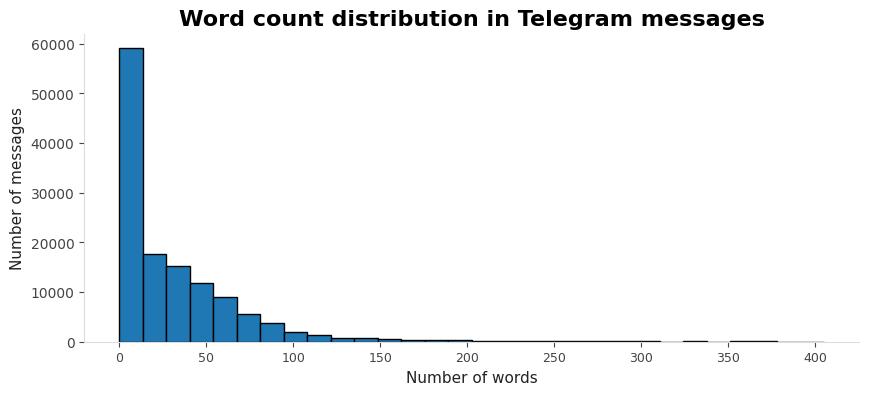

In [472]:
df_tg['word_count'] = df_tg['message_clean'].str.split().str.len()

plt.figure(figsize=(10, 4))
plt.hist(df_tg['word_count'], bins=30, edgecolor='black')  # bins = кількість стовпчиків

plt.title('Word count distribution in Telegram messages')
plt.xlabel('Number of words')
plt.ylabel('Number of messages')

plt.show()

In [473]:
sparsity_tg = (1 - X_tg.nnz / (X_tg.shape[0] * X_tg.shape[1])) * 100
print(f"Sparsity of matrix Telegram: {sparsity_tg:.4f}%")

Sparsity of matrix Telegram: 99.4310%


## V. Prepare for merge

In [474]:
df_isw = df_isw.drop(columns=["is_alarm"], errors="ignore")
df_tg = df_tg.drop(columns=["is_alarm"], errors="ignore")

### War events (alarms)

In [475]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,13.0,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,25.0,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,2.0,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,20.0,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,19.0,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [476]:
df_war_events = df_war_events[df_war_events["duration_min"] >= 0].copy()
print("Shape after removing negative durations:", df_war_events.shape)

Shape after removing negative durations: (55787, 8)


In [477]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())

Negative durations: 0


In [ ]:
rows = []

for row in df_war_events[["id", "region_id", "region_key", "start", "end"]].itertuples(index=False):
    start_hour = row.start.floor("h")
    end_hour = row.end.floor("h")

    for hour in pd.date_range(start_hour, end_hour, freq="h"):
        hour_end = hour + pd.Timedelta(hours=1)

        overlap_start = max(row.start, hour)
        overlap_end = min(row.end, hour_end)

        overlap_min = (overlap_end - overlap_start).total_seconds() / 60

        if overlap_min > 0:
            rows.append({
                "datetime_hour": hour,
                "region_id": row.region_id,
                "region_key": row.region_key,
                "alarm_minutes_in_hour": overlap_min,
                "alarm_active": 1,
                "alarm_id": row.id
            })

df_alarm_hourly = pd.DataFrame(rows)

df_alarm_hourly = (
    df_alarm_hourly
    .groupby(["datetime_hour", "region_id", "region_key"], as_index=False)
    .agg(
        alarm_minutes_in_hour=("alarm_minutes_in_hour", "sum"),
        alarm_active=("alarm_active", "max"),
    )
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly["alarm_minutes_in_hour"] = df_alarm_hourly["alarm_minutes_in_hour"].clip(0, 60)

print(df_alarm_hourly[["region_id", "region_key"]].drop_duplicates())

In [ ]:
all_hours = pd.date_range(
    df_weather["datetime_hour"].min(),
    df_weather["datetime_hour"].max(),
    freq="h"
)

regions_dim = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region": "region_key"})
)

kyiv_row = pd.DataFrame([{
    "region_id": 26,
    "region_key": "Київ"
}])

regions_dim = (
    pd.concat([regions_dim, kyiv_row], ignore_index=True)
    .drop_duplicates(subset=["region_id", "region_key"])
    .sort_values("region_id")
    .reset_index(drop=True)
)

backbone = (
    pd.MultiIndex.from_product(
        [all_hours, regions_dim["region_id"]],
        names=["datetime_hour", "region_id"]
    )
    .to_frame(index=False)
    .merge(regions_dim, on="region_id", how="left")
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly_full = backbone.merge(
    df_alarm_hourly,
    on=["datetime_hour", "region_id", "region_key"],
    how="left"
)

for col in ["alarm_minutes_in_hour", "alarm_active"]:
    df_alarm_hourly_full[col] = df_alarm_hourly_full[col].fillna(0)

df_alarm_hourly_full["alarm_active"] = df_alarm_hourly_full["alarm_active"].astype(int)
df_alarm_hourly_full["date"] = df_alarm_hourly_full["datetime_hour"].dt.floor("D")
df_alarm_hourly_full["hour"] = df_alarm_hourly_full["datetime_hour"].dt.hour
df_alarm_hourly_full["month"] = df_alarm_hourly_full["datetime_hour"].dt.month
df_alarm_hourly_full["weekday"] = df_alarm_hourly_full["datetime_hour"].dt.weekday

print(df_alarm_hourly_full[["region_id", "region_key"]].drop_duplicates())

In [ ]:
def last_sunday_of_march(year):
    cal = monthcalendar(year, 3)
    day = max(week[SUNDAY] for week in cal)
    return pd.Timestamp(year=year, month=3, day=day, hour=3)

years = sorted(df_alarm_hourly_full["datetime_hour"].dt.year.unique())

spring_missing_hours = pd.to_datetime([last_sunday_of_march(y) for y in years])

print("Spring hours to remove:")
print(spring_missing_hours)

mask_spring = df_alarm_hourly_full["datetime_hour"].isin(spring_missing_hours)

print("Rows to remove from war_events:", mask_spring.sum())
print(df_alarm_hourly_full.loc[mask_spring, ["datetime_hour", "region_id", "region_key"]].head(10))

df_alarm_hourly_full = (
    df_alarm_hourly_full.loc[~mask_spring]
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

print("War events shape after removing spring hour:", df_alarm_hourly_full.shape)

### Weather 

In [ ]:
city_to_region = {
    "Vinnytsia": "Вінницька",
    "Lutsk": "Волинська",
    "Dnipro": "Дніпропетровська",
    "Donetsk": "Донецька",
    "Zhytomyr": "Житомирська",
    "Uzhgorod": "Закарпатська",
    "Zaporozhye": "Запорізька",
    "Ivano-Frankivsk": "Івано-Франківська",
    "Kyiv": "Київ",
    "Kropyvnytskyi": "Кіровоградська",
    "Luhansk": "Луганська",
    "Lviv": "Львівська",
    "Mykolaiv": "Миколаївська",
    "Odesa": "Одеська",
    "Poltava": "Полтавська",
    "Rivne": "Рівненська",
    "Sumy": "Сумська",
    "Ternopil": "Тернопільська",
    "Kharkiv": "Харківська",
    "Kherson": "Херсонська",
    "Khmelnytskyi": "Хмельницька",
    "Cherkasy": "Черкаська",
    "Chernivtsi": "Чернівецька",
    "Chernihiv": "Чернігівська",
    "Simferopol": "АР Крим"
}

df_weather["region_key"] = df_weather["city_name"].map(city_to_region)

region_id_map = df_regions.set_index("region")["region_id"].to_dict()
region_id_map["Київ"] = 26

df_weather["region_id"] = df_weather["region_key"].map(region_id_map)

kyiv_weather = df_weather[df_weather["region_id"] == 26].copy()
kyivska_weather = kyiv_weather.copy()

kyivska_weather["region_id"] = 10
kyivska_weather["region_key"] = "Київська"

df_weather = (
    pd.concat([df_weather, kyivska_weather], ignore_index=True)
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

print(df_weather[["city_name", "region_key", "region_id"]].drop_duplicates())
print("Missing region_id:", df_weather["region_id"].isna().sum())

In [ ]:
print("Weather duplicates BEFORE:", df_weather.duplicated(["datetime_hour", "region_id"]).sum())

key_cols = ["datetime_hour", "region_id"]
helper_cols = ["year", "month", "day_of_week", "hour"]

bool_cols = df_weather.select_dtypes(include="bool").columns.tolist()
num_cols = [
    c for c in df_weather.select_dtypes(include=["number"]).columns
    if c not in key_cols + helper_cols
]
other_cols = [
    c for c in df_weather.columns
    if c not in key_cols + helper_cols + bool_cols + num_cols
]

agg_dict = {c: "mean" for c in num_cols}
agg_dict.update({c: "max" for c in bool_cols})
agg_dict.update({c: "first" for c in helper_cols + other_cols})

df_weather = (
    df_weather
    .groupby(key_cols, as_index=False)
    .agg(agg_dict)
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

print("Weather duplicates AFTER:", df_weather.duplicated(["datetime_hour", "region_id"]).sum())
print(df_weather.shape)

In [ ]:
df_alarm_hourly_full.to_csv("war_events_processed.csv", index=False, encoding="utf-8-sig")
# df_isw.to_csv("isw_processed.csv", index=False, encoding="utf-8-sig")
# df_tg.to_csv("telegram_processed.csv", index=False, encoding="utf-8-sig")
df_weather.to_csv("weather_processed.csv", index=False, encoding="utf-8-sig")

In [ ]:
df_matrix = pd.DataFrame(
    X.toarray(),
    columns=[f"isw_tfidf_{w}" for w in vectorizer.get_feature_names_out()]
)

df_isw_matrix = pd.concat(
    [df_isw[["date"]].reset_index(drop=True), df_matrix.reset_index(drop=True)],
    axis=1
)

df_isw_matrix.to_csv("matrix_isw.csv", index=False)